# 📊 Avaliação de Modelo Fine-Tuned com LoRA

Este notebook avalia o modelo **google/flan-t5-xl** fine-tuned com LoRA
usando as principais métricas de NLP. O dataset é o conjunto de Q&A de neurociência cognitiva.

---

## 🗺️ Métricas Avaliadas

| Métrica | Foco | Intervalo Típico |
|---|---|---|
| **Perplexidade (PPL)** | Capacidade preditiva do modelo | Menor = melhor |
| **BLEU** | Precisão de n-gramas vs. referência | 0–100 (maior = melhor) |
| **ROUGE** | Recall de sobreposição de conteúdo | 0–1 (maior = melhor) |
| **Fidelidade (Faithfulness)** | Se a resposta é fiel ao contexto | 0–1 (maior = melhor) |
| **Relevância da Resposta** | Se a resposta é útil à pergunta | 0–1 (maior = melhor) |
| **Aderência ao Plano** | Se o agente segue o plano de ação | 0–1 (maior = melhor) |

---


## 📦 Célula 1 — Instalação de Dependências

Instalamos todas as bibliotecas necessárias. Execute uma única vez.

In [1]:
# Execute esta célula apenas uma vez antes de prosseguir.
!pip install -q transformers peft torch sacrebleu rouge-score nltk pandas \
             matplotlib seaborn tqdm bitsandbytes accelerate

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Todas as dependências instaladas com sucesso!')



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Todas as dependências instaladas com sucesso!


## 🔌 Célula 2 — Importações

Importamos todas as bibliotecas que serão usadas ao longo do notebook.

In [2]:
import json
import math
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

# Transformers & PEFT
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# Métricas NLP
from sacrebleu.metrics import BLEU
from rouge_score import rouge_scorer
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Importações concluídas!')
print(f'   PyTorch: {torch.__version__}')
print(f'   Dispositivo disponível: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')


Matplotlib is building the font cache; this may take a moment.
c:\Users\Aluno\Documents\estudo_ia\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Importações concluídas!
   PyTorch: 2.12.0+cpu
   Dispositivo disponível: CPU


## 📂 Célula 3 — Carregamento do Dataset

Lemos o arquivo `dataset_curado.jsonl`. Cada linha contém:
- **`Instruction`**: a pergunta de neurociência cognitiva
- **`Output`**: resposta esperada (ground truth)


In [3]:
DATASET_PATH = 'data/processed/dataset_curado.jsonl'

samples = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            samples.append(json.loads(line))

print(f'✅ Dataset carregado com {len(samples)} amostras.\n')

df_raw = pd.DataFrame(samples)
df_raw[['Instruction', 'Output']].head(3).style \
    .set_caption('📋 Primeiras amostras do dataset') \
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})


✅ Dataset carregado com 10 amostras.



,instruction,input,output
0,What is the recommended oil change interval for my vehicle?,"Make: Toyota, Model: Camry 2021","For your 2021 Toyota Camry, Toyota recommends: - Conventional oil: Every 5,000 miles or 6 months - Synthetic oil: Every 10,000 miles or 12 months - Severe conditions: Reduce interval by 20%"
1,How do I pair my phone with Bluetooth?,Car model: Honda Accord 2022,"To pair your phone with a 2022 Honda Accord: 1. Go to Settings > Bluetooth on your phone 2. On the car's infotainment, select 'Phone Setup' 3. Choose 'Add New Device' 4. Select your phone from the list 5. Confirm the pairing code on both devices"
2,What does the check engine light indicate?,,The check engine light can indicate: 1. Emissions system malfunction 2. Fuel system issues 3. Ignition system problems 4. Sensor failures 5. Transmission issues Have the vehicle scanned for diagnostic trouble codes (DTCs) immediately.


## 🤖 Célula 4 — Carregamento do Modelo Fine-Tuned

Carregamos o **Flan-T5-XL** em 4-bit (QLoRA) e aplicamos os adaptadores
LoRA salvos em `lora_models/seq2seq_model_1/final_adapter`.

> **ℹ️ Arquitetura seq2seq:** O Flan-T5 é um modelo encoder-decoder.
> Por isso usamos `AutoModelForSeq2SeqLM` em vez de `AutoModelForCausalLM`,
> e a perplexidade é calculada apenas sobre os tokens da saída (decoder),
> não sobre o prompt completo.


In [4]:
MODEL_BASE      = 'google/flan-t5-xl'
LORA_MODEL_PATH = 'lora_models/seq2seq_model_1/final_adapter'
TOKENIZER_PATH  = 'lora_models/seq2seq_model_1/final_tokenizer'
PREFIX          = 'Responda sobre neurociência cognitiva: '

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print('⏳ Carregando tokenizer...')
# Carrega do modelo base — evita incompatibilidade de versão do TokenizersBackend
# O tokenizador não muda com fine-tuning LoRA
finetuned_tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE)
if finetuned_tokenizer.pad_token is None:
    finetuned_tokenizer.pad_token = finetuned_tokenizer.eos_token

print('⏳ Carregando modelo base em 4-bit...')
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_BASE,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)

print('⏳ Aplicando adaptadores LoRA...')
finetuned_model = PeftModel.from_pretrained(base_model, LORA_MODEL_PATH)
finetuned_model.eval()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

total_params     = sum(p.numel() for p in finetuned_model.parameters())
trainable_params = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)

print(f'\n✅ Modelo carregado!')
print(f'   Base            : {MODEL_BASE}')
print(f'   Dispositivo     : {DEVICE}')
print(f'   Parâmetros totais: {total_params:,}')
print(f'   Parâmetros LoRA : {trainable_params:,}')
print(f'   Redução LoRA    : {(1 - trainable_params/total_params)*100:.1f}% do total')


⏳ Carregando tokenizer...
⏳ Carregando modelo base...


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 11046.44it/s]


⏳ Aplicando adaptadores LoRA...

✅ Modelo carregado no dispositivo: cpu
   Parâmetros totais   : 82,723,584
   Parâmetros LoRA     : 0
   Redução LoRA        : 100.0% do total


## ✍️ Célula 5 — Função de Geração de Respostas

Definimos a função central de geração para o Flan-T5-XL.

> **Diferença do Phi-4-mini / Llama 3.2:** Modelos causais concatenam prompt e resposta
> num único texto. No Flan-T5, a entrada vai para o **encoder** e a saída é gerada
> pelo **decoder** de forma independente — sem chat template, sem `apply_chat_template`.
> O prefixo `PREFIX` sinaliza a tarefa ao modelo, como foi feito no fine-tuning.


In [ ]:
def generate_response(
    model,
    tokenizer,
    instruction: str,
    input_text: str = '',
    max_new_tokens: int = 200,
    num_beams: int = 4,
) -> str:
    """
    Geração para modelos seq2seq (encoder-decoder).
    A entrada vai para o encoder com o PREFIX de tarefa;
    o decoder gera a saída de forma independente.
    Sem chat template — o Flan-T5 não usa esse formato.
    """
    inputs = tokenizer(
        PREFIX + instruction,
        return_tensors='pt',
        truncation=True,
        max_length=256,
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
        )

    # No seq2seq, output_ids[0] contém apenas os tokens gerados (sem o prompt)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


print('✅ Função de geração definida!')

# Teste rápido
sample = samples[0]
test_response = generate_response(
    finetuned_model, finetuned_tokenizer,
    sample['Instruction']
)
print(f'\n🧪 Teste rápido com a primeira amostra:')
print(f'   📌 Instrução : {sample["Instruction"]}')
print(f'   ✅ Esperado  : {sample["Output"][:80]}...')
print(f'   🤖 Gerado    : {test_response[:80]}...')


✅ Funções de geração definidas!

🧪 Teste rápido com a primeira amostra:
   📌 Instrução : What is the recommended oil change interval for my vehicle?
   📥 Contexto  : Make: Toyota, Model: Camry 2021
   ✅ Esperado  : For your 2021 Toyota Camry, Toyota recommends:
- Conventional oil: Every 5,000 m...
   🤖 Gerado    : - Musty odors: Every 10,000 miles
- Severe conditions: Reduce interval by 20%

A...


## 📏 Célula 6 — Métrica 1: Perplexidade (PPL)

### O que é?
A **Perplexidade** mede o quão surpreso o modelo fica ao ver o texto de referência. É calculada a partir da **log-verossimilhança negativa média** por token:

$$\text{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i | w_1, \dots, w_{i-1})\right)$$

- **PPL baixa** → o modelo prevê bem o texto de referência → melhor desempenho.
- **PPL = 1** → previsão perfeita (impossível na prática).
- **PPL alta** → o modelo está "confuso" com o texto.

### Como é calculada aqui?
Para cada amostra, passamos o **texto de referência** (output esperado) pelo modelo e calculamos a loss (cross-entropy), depois convertemos para PPL.

In [6]:
def compute_perplexity_for_sample(
    model, tokenizer, instruction: str, reference: str
) -> float:
    """
    Calcula a Perplexidade para modelos seq2seq.
    Diferença dos modelos causais: a loss é calculada apenas sobre os tokens
    da saída (decoder), não sobre o prompt — o que é semanticamente mais correto
    para avaliar a qualidade da geração do Flan-T5.
    """
    # Encoder recebe a entrada com prefixo
    input_enc = tokenizer(
        PREFIX + instruction,
        return_tensors='pt',
        truncation=True,
        max_length=256,
    ).to(model.device)

    # Labels: tokens da resposta de referência
    # Padding mascarado com -100 para não entrar na loss
    label_enc = tokenizer(
        reference,
        return_tensors='pt',
        truncation=True,
        max_length=256,
        padding=True,
    ).to(model.device)

    labels = label_enc['input_ids'].clone()
    labels[labels == tokenizer.pad_token_id] = -100

    with torch.no_grad():
        outputs = model(
            input_ids=input_enc['input_ids'],
            attention_mask=input_enc['attention_mask'],
            labels=labels,
        )
        loss = outputs.loss

    return math.exp(loss.item())


print('⏳ Calculando Perplexidade para todas as amostras...')
ppl_scores = []
for s in tqdm(samples, desc='PPL'):
    ppl = compute_perplexity_for_sample(
        finetuned_model, finetuned_tokenizer,
        s['Instruction'], s['Output']
    )
    ppl_scores.append(ppl)

mean_ppl = np.mean(ppl_scores)
print(f'\n📊 Perplexidade Média : {mean_ppl:.2f}')
print(f'   Mínima            : {min(ppl_scores):.2f}  (amostra mais fácil)')
print(f'   Máxima            : {max(ppl_scores):.2f}  (amostra mais difícil)')
print(f'\n💡 Interpretação: PPL = {mean_ppl:.1f} significa que, em média,')
print(f'   o modelo considera ~{mean_ppl:.0f} próximas palavras igualmente prováveis.')


⏳ Calculando Perplexidade para todas as amostras...


PPL: 100%|██████████| 10/10 [00:00<00:00, 11.16it/s]


📊 Perplexidade Média : 12.38
   Mínima            : 1.12  (amostra mais fácil)
   Máxima            : 59.68  (amostra mais difícil)

💡 Interpretação: PPL = 12.4 significa que, em média,
   o modelo considera ~12 próximas palavras igualmente prováveis.


## 🔵 Célula 7 — Métrica 2: BLEU

### O que é?
O **BLEU** (Bilingual Evaluation Understudy) mede a **precisão de n-gramas** entre o texto gerado e uma referência.

$$\text{BLEU} = \text{BP} \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

onde:
- $p_n$ = precisão de n-gramas (1-gram, 2-gram, 3-gram, 4-gram)
- **BP** = Brevity Penalty (penaliza respostas muito curtas)
- Escala de 0 a 100 (ou 0 a 1)

### Limitações
BLEU foca em **precisão** — se todos os n-gramas gerados aparecem na referência. Ele não captura bem paráfrases ou sinônimos.

In [7]:
def compute_bleu(hypotheses: list, references: list) -> dict:
    bleu = BLEU(effective_order=True)
    result = bleu.corpus_score(hypotheses, [references])
    return {
        'bleu_score'     : result.score,
        '1-gram'         : result.precisions[0],
        '2-gram'         : result.precisions[1],
        '3-gram'         : result.precisions[2],
        '4-gram'         : result.precisions[3],
        'brevity_penalty': result.bp,
    }


print('⏳ Gerando respostas do modelo para calcular BLEU...')
generated_responses = []
reference_outputs   = []

for s in tqdm(samples, desc='Gerando'):
    gen = generate_response(
        finetuned_model, finetuned_tokenizer,
        s['Instruction']           # campo correto do dataset curado
    )
    generated_responses.append(gen)
    reference_outputs.append(s['Output'])

bleu_results = compute_bleu(generated_responses, reference_outputs)

print(f'\n📊 Resultados BLEU:')
print(f'   BLEU Score (corpus)  : {bleu_results["bleu_score"]:.2f}')
print(f'   Precisão 1-gram      : {bleu_results["1-gram"]:.2f}%')
print(f'   Precisão 2-gram      : {bleu_results["2-gram"]:.2f}%')
print(f'   Precisão 3-gram      : {bleu_results["3-gram"]:.2f}%')
print(f'   Precisão 4-gram      : {bleu_results["4-gram"]:.2f}%')
print(f'   Brevity Penalty      : {bleu_results["brevity_penalty"]:.4f}')
print(f'\n💡 BLEU > 30 é geralmente considerado bom para geração de texto.')


⏳ Gerando respostas do modelo para calcular BLEU...


Gerando: 100%|██████████| 10/10 [01:24<00:00,  8.46s/it]


📊 Resultados BLEU:
   BLEU Score (corpus)  : 12.82
   Precisão 1-gram      : 17.52%
   Precisão 2-gram      : 13.38%
   Precisão 3-gram      : 11.38%
   Precisão 4-gram      : 10.13%
   Brevity Penalty      : 1.0000

💡 BLEU > 30 é geralmente considerado bom para geração de texto.


## 🟢 Célula 8 — Métrica 3: ROUGE

### O que é?
**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) complementa o BLEU focando no **recall** — quanta informação da referência aparece na resposta gerada.

| Variante | O que mede |
|---|---|
| **ROUGE-1** | Sobreposição de unigramas (palavras individuais) |
| **ROUGE-2** | Sobreposição de bigramas (pares de palavras) |
| **ROUGE-L** | Subsequência Comum mais Longa (LCS) — captura ordem |

Cada métrica retorna **Precisão**, **Recall** e **F1** (harmônica entre os dois).

In [8]:
# ============================================================
#  MÉTRICA 3 — ROUGE
# ============================================================

def compute_rouge_scores(hypotheses: list, references: list) -> pd.DataFrame:
    """
    Calcula ROUGE-1, ROUGE-2 e ROUGE-L para cada par (gerado, referência).

    Retorna um DataFrame com Precision, Recall e F1 para cada variante.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    records = []

    for hyp, ref in zip(hypotheses, references):
        scores = scorer.score(ref, hyp)
        records.append({
            'ROUGE-1 P' : scores['rouge1'].precision,
            'ROUGE-1 R' : scores['rouge1'].recall,
            'ROUGE-1 F1': scores['rouge1'].fmeasure,
            'ROUGE-2 P' : scores['rouge2'].precision,
            'ROUGE-2 R' : scores['rouge2'].recall,
            'ROUGE-2 F1': scores['rouge2'].fmeasure,
            'ROUGE-L P' : scores['rougeL'].precision,
            'ROUGE-L R' : scores['rougeL'].recall,
            'ROUGE-L F1': scores['rougeL'].fmeasure,
        })

    return pd.DataFrame(records)


df_rouge = compute_rouge_scores(generated_responses, reference_outputs)

print('📊 Médias ROUGE (todas as amostras):\n')
rouge_means = df_rouge.mean()

for variant in ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']:
    p  = rouge_means[f'{variant} P']
    r  = rouge_means[f'{variant} R']
    f1 = rouge_means[f'{variant} F1']
    print(f'   {variant:<8}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}')

print(f'\n💡 ROUGE-L F1 alto indica que o modelo mantém a ordem e estrutura do texto de referência.')

📊 Médias ROUGE (todas as amostras):

   ROUGE-1   Precision=0.172  Recall=0.503  F1=0.253
   ROUGE-2   Precision=0.127  Recall=0.366  F1=0.187
   ROUGE-L   Precision=0.153  Recall=0.445  F1=0.225

💡 ROUGE-L F1 alto indica que o modelo mantém a ordem e estrutura do texto de referência.


## 🟠 Célula 9 — Métrica 4: Fidelidade (Faithfulness)

### O que é?
A **Fidelidade** avalia se a resposta gerada é **factualmente consistente** com o contexto de entrada (instruction + input). É crítica em sistemas **RAG** (Retrieval-Augmented Generation).

### Como é calculada aqui?
Usamos uma abordagem léxica baseada em **sobreposição de tokens importantes**:
1. Extraímos tokens significativos do contexto (substantivos, números, marcas)
2. Calculamos a fração presente na resposta gerada

> ⚠️ **Nota:** Em produção, Faithfulness é melhor avaliada por um modelo de NLI (Natural Language Inference) como DeBERTa ou via LLM-as-judge.

In [ ]:
def extract_key_tokens(text: str) -> set:
    STOPWORDS = {
        'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
        'could', 'should', 'may', 'might', 'to', 'of', 'in', 'on',
        'at', 'for', 'with', 'by', 'from', 'or', 'and', 'but', 'if',
        'your', 'my', 'our', 'their', 'this', 'that', 'it', 'its',
        # stopwords em português
        'que', 'para', 'com', 'uma', 'por', 'são', 'como', 'mais',
        'dos', 'das', 'nos', 'nas', 'ele', 'ela', 'seu', 'sua',
    }
    tokens = re.findall(r'[A-Za-zÀ-ú0-9]+', text.lower())
    return {
        t for t in tokens
        if (t.isdigit() or len(t) >= 4) and t not in STOPWORDS
    }


def compute_faithfulness(instruction: str, generated: str) -> float:
    context_tokens   = extract_key_tokens(instruction)
    generated_tokens = extract_key_tokens(generated)
    if not context_tokens:
        return 0.5
    overlap = context_tokens & generated_tokens
    return len(overlap) / len(context_tokens)


faithfulness_scores = []
for s, gen in zip(samples, generated_responses):
    score = compute_faithfulness(s['Instruction'], gen)
    faithfulness_scores.append(score)

mean_faith = np.mean(faithfulness_scores)
print(f'📊 Fidelidade (Faithfulness):')
print(f'   Média  : {mean_faith:.3f}')
print(f'   Mínima : {min(faithfulness_scores):.3f}')
print(f'   Máxima : {max(faithfulness_scores):.3f}')
print(f'\n💡 Score próximo de 1.0 indica que a resposta cita informações do contexto.')


📊 Fidelidade (Faithfulness):
   Média  : 0.239
   Mínima : 0.000
   Máxima : 0.600

💡 Score próximo de 1.0 indica que a resposta cita informações do contexto fornecido.
   Crítico em sistemas RAG onde o modelo deve se basear nos documentos recuperados.


## 🟡 Célula 10 — Métrica 5: Relevância da Resposta (Answer Relevance)

### O que é?
A **Relevância** mede se a resposta realmente **responde à pergunta feita**. Uma resposta pode ser fluente e fiel ao contexto, mas não responder à instrução específica.

### Como é calculada aqui?
Usamos **Jaccard Similarity** sobre tokens-chave entre a instrução e a resposta gerada:

$$\text{Relevância} = \frac{|\text{tokens}_{\text{instrução}} \cap \text{tokens}_{\text{resposta}}|}{|\text{tokens}_{\text{instrução}} \cup \text{tokens}_{\text{resposta}}|}$$

> ⚠️ Em produção, use embeddings semânticos (sentence-transformers) ou LLM-as-judge para maior precisão.

In [10]:
def compute_answer_relevance(instruction: str, generated: str) -> float:
    instr_tokens = extract_key_tokens(instruction)
    gen_tokens   = extract_key_tokens(generated)
    if not instr_tokens and not gen_tokens:
        return 0.5
    intersection = instr_tokens & gen_tokens
    union        = instr_tokens | gen_tokens
    jaccard  = len(intersection) / len(union)
    coverage = len(intersection) / len(instr_tokens) if instr_tokens else 0
    return (jaccard + coverage) / 2.0


relevance_scores = [
    compute_answer_relevance(s['Instruction'], gen)
    for s, gen in zip(samples, generated_responses)
]

mean_rel = np.mean(relevance_scores)
print(f'📊 Relevância da Resposta:')
print(f'   Média  : {mean_rel:.3f}')
print(f'   Mínima : {min(relevance_scores):.3f}')
print(f'   Máxima : {max(relevance_scores):.3f}')
print(f'\n💡 Score alto = resposta usa o vocabulário da pergunta e cobre seus aspectos principais.')


📊 Relevância da Resposta:
   Média  : 0.214
   Mínima : 0.000
   Máxima : 0.373

💡 Score alto = resposta usa o vocabulário da pergunta e cobre seus aspectos principais.


## 🔴 Célula 11 — Métrica 6: Aderência ao Plano (Plan Adherence)

### O que é?
A **Aderência ao Plano** mede se o agente de IA segue a estrutura esperada de resposta — relevante em contextos de **AI Agents** que devem seguir planos de ação predefinidos.

### Como é calculada aqui?
Para nosso dataset automotivo, o "plano" esperado é a estrutura do output de referência:
- ✅ Numeração de passos (`1. 2. 3.`)
- ✅ Uso de bullet points (`-`, `•`)
- ✅ Formato de valores técnicos (ex.: `35 psi`, `10,000 miles`)
- ✅ Presença de seções com dois-pontos

Avaliamos se a resposta gerada segue os mesmos **elementos estruturais** que a referência.

In [11]:
def detect_structural_elements(text: str) -> dict:
    return {
        'has_numbered_list': bool(re.search(r'^\d+\.\s', text, re.MULTILINE)),
        'has_bullets'      : bool(re.search(r'^[\-•]\s', text, re.MULTILINE)),
        'has_technical'    : bool(re.search(
            r'\d+[,.]?\d*\s*(neurônios?|córtex|Hz|ms|mm|mg|kg|anos?|%)',
            text, re.IGNORECASE
        )),
        'has_sections'     : bool(re.search(r'^[A-ZÀ-Ú][^\n]+:\s*$', text, re.MULTILINE)),
        'step_count'       : len(re.findall(r'^\d+\.\s', text, re.MULTILINE)),
    }


def compute_plan_adherence(reference: str, generated: str) -> float:
    ref_struct = detect_structural_elements(reference)
    gen_struct = detect_structural_elements(generated)
    checks = []
    for feat in ['has_numbered_list', 'has_bullets', 'has_technical', 'has_sections']:
        if ref_struct[feat]:
            checks.append(1.0 if gen_struct[feat] else 0.0)
    if ref_struct['step_count'] > 0:
        step_ratio = min(gen_struct['step_count'], ref_struct['step_count']) / \
                     max(gen_struct['step_count'], ref_struct['step_count'], 1)
        checks.append(step_ratio)
    return np.mean(checks) if checks else 0.5


plan_scores = [
    compute_plan_adherence(s['Output'], gen)
    for s, gen in zip(samples, generated_responses)
]

mean_plan = np.mean(plan_scores)
print(f'📊 Aderência ao Plano (Plan Adherence):')
print(f'   Média  : {mean_plan:.3f}')
print(f'   Mínima : {min(plan_scores):.3f}')
print(f'   Máxima : {max(plan_scores):.3f}')
print(f'\n💡 Score alto indica que o modelo segue a mesma estrutura de resposta da referência.')


📊 Aderência ao Plano (Plan Adherence):
   Média  : 0.699
   Mínima : 0.400
   Máxima : 1.000

💡 Score alto indica que o modelo segue a mesma estrutura de resposta da referência:
   listas numeradas, bullets, valores técnicos e organização em seções.


## 📋 Célula 12 — Tabela Consolidada de Resultados

Unificamos todos os scores por amostra em um único DataFrame para análise comparativa.

In [12]:
# ============================================================
#  TABELA CONSOLIDADA DE RESULTADOS
# ============================================================

rouge_f1_1 = df_rouge['ROUGE-1 F1'].tolist()
rouge_f1_2 = df_rouge['ROUGE-2 F1'].tolist()
rouge_f1_L = df_rouge['ROUGE-L F1'].tolist()

# BLEU por amostra (sacrebleu sentence-level)
bleu_metric = BLEU(effective_order=True)
bleu_per_sample = [
    bleu_metric.sentence_score(hyp, [ref]).score
    for hyp, ref in zip(generated_responses, reference_outputs)
]

df_results = pd.DataFrame({
    'Instrução'           : [s['Instruction'][:50] + '...' for s in samples],
    'PPL'                 : [round(p, 2) for p in ppl_scores],
    'BLEU'                : [round(b, 2) for b in bleu_per_sample],
    'ROUGE-1 F1'          : [round(r, 3) for r in rouge_f1_1],
    'ROUGE-2 F1'          : [round(r, 3) for r in rouge_f1_2],
    'ROUGE-L F1'          : [round(r, 3) for r in rouge_f1_L],
    'Faithfulness'        : [round(f, 3) for f in faithfulness_scores],
    'Answer Relevance'    : [round(r, 3) for r in relevance_scores],
    'Plan Adherence'      : [round(p, 3) for p in plan_scores],
})

# Linha de médias
means_row = pd.DataFrame([{
    'Instrução'        : '📊 MÉDIA',
    'PPL'              : round(np.mean(ppl_scores), 2),
    'BLEU'             : round(np.mean(bleu_per_sample), 2),
    'ROUGE-1 F1'       : round(np.mean(rouge_f1_1), 3),
    'ROUGE-2 F1'       : round(np.mean(rouge_f1_2), 3),
    'ROUGE-L F1'       : round(np.mean(rouge_f1_L), 3),
    'Faithfulness'     : round(np.mean(faithfulness_scores), 3),
    'Answer Relevance' : round(np.mean(relevance_scores), 3),
    'Plan Adherence'   : round(np.mean(plan_scores), 3),
}])

df_display = pd.concat([df_results, means_row], ignore_index=True)

def highlight_mean_row(row):
    if row['Instrução'] == '📊 MÉDIA':
        return ['background-color: #1a1a2e; color: #e0e0e0; font-weight: bold'] * len(row)
    return [''] * len(row)

styled = (
    df_display.style
    .apply(highlight_mean_row, axis=1)
    .background_gradient(subset=['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1',
                                  'Faithfulness', 'Answer Relevance', 'Plan Adherence'],
                         cmap='YlGn', vmin=0, vmax=1)
    .background_gradient(subset=['PPL'], cmap='YlOrRd_r')
    .set_caption('📋 Resultados por Amostra — Todas as Métricas')
)

styled

,Instrução,PPL,BLEU,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Faithfulness,Answer Relevance,Plan Adherence
0,What is the recommended oil change interval for my...,1.260000,2.380000,0.140000,0.047000,0.081000,0.200000,0.232000,0.667000
1,How do I pair my phone with Bluetooth?...,52.970000,0.290000,0.055000,0.000000,0.045000,0.143000,0.205000,0.400000
2,What does the check engine light indicate?...,1.120000,2.030000,0.135000,0.034000,0.101000,0.600000,0.356000,0.833000
3,How do I jump start my car?...,1.220000,33.900000,0.559000,0.500000,0.541000,0.500000,0.261000,0.444000
4,What is the proper tire pressure for my vehicle?...,59.680000,0.280000,0.000000,0.000000,0.000000,0.000000,0.000000,0.667000
5,How do I reset the maintenance light?...,1.150000,30.790000,0.451000,0.420000,0.427000,0.125000,0.188000,0.667000
6,What is the towing capacity of my SUV?...,2.590000,9.700000,0.185000,0.154000,0.185000,0.182000,0.193000,1.000000
7,How often should I replace the cabin air filter?...,1.280000,19.340000,0.341000,0.276000,0.330000,0.250000,0.137000,1.000000
8,What type of gasoline should I use?...,1.400000,12.900000,0.251000,0.206000,0.228000,0.143000,0.198000,0.667000
9,How do I activate cruise control?...,1.190000,18.260000,0.415000,0.232000,0.317000,0.250000,0.373000,0.646000


## 📈 Célula 13 — Visualizações

Gráficos que facilitam a interpretação dos resultados.

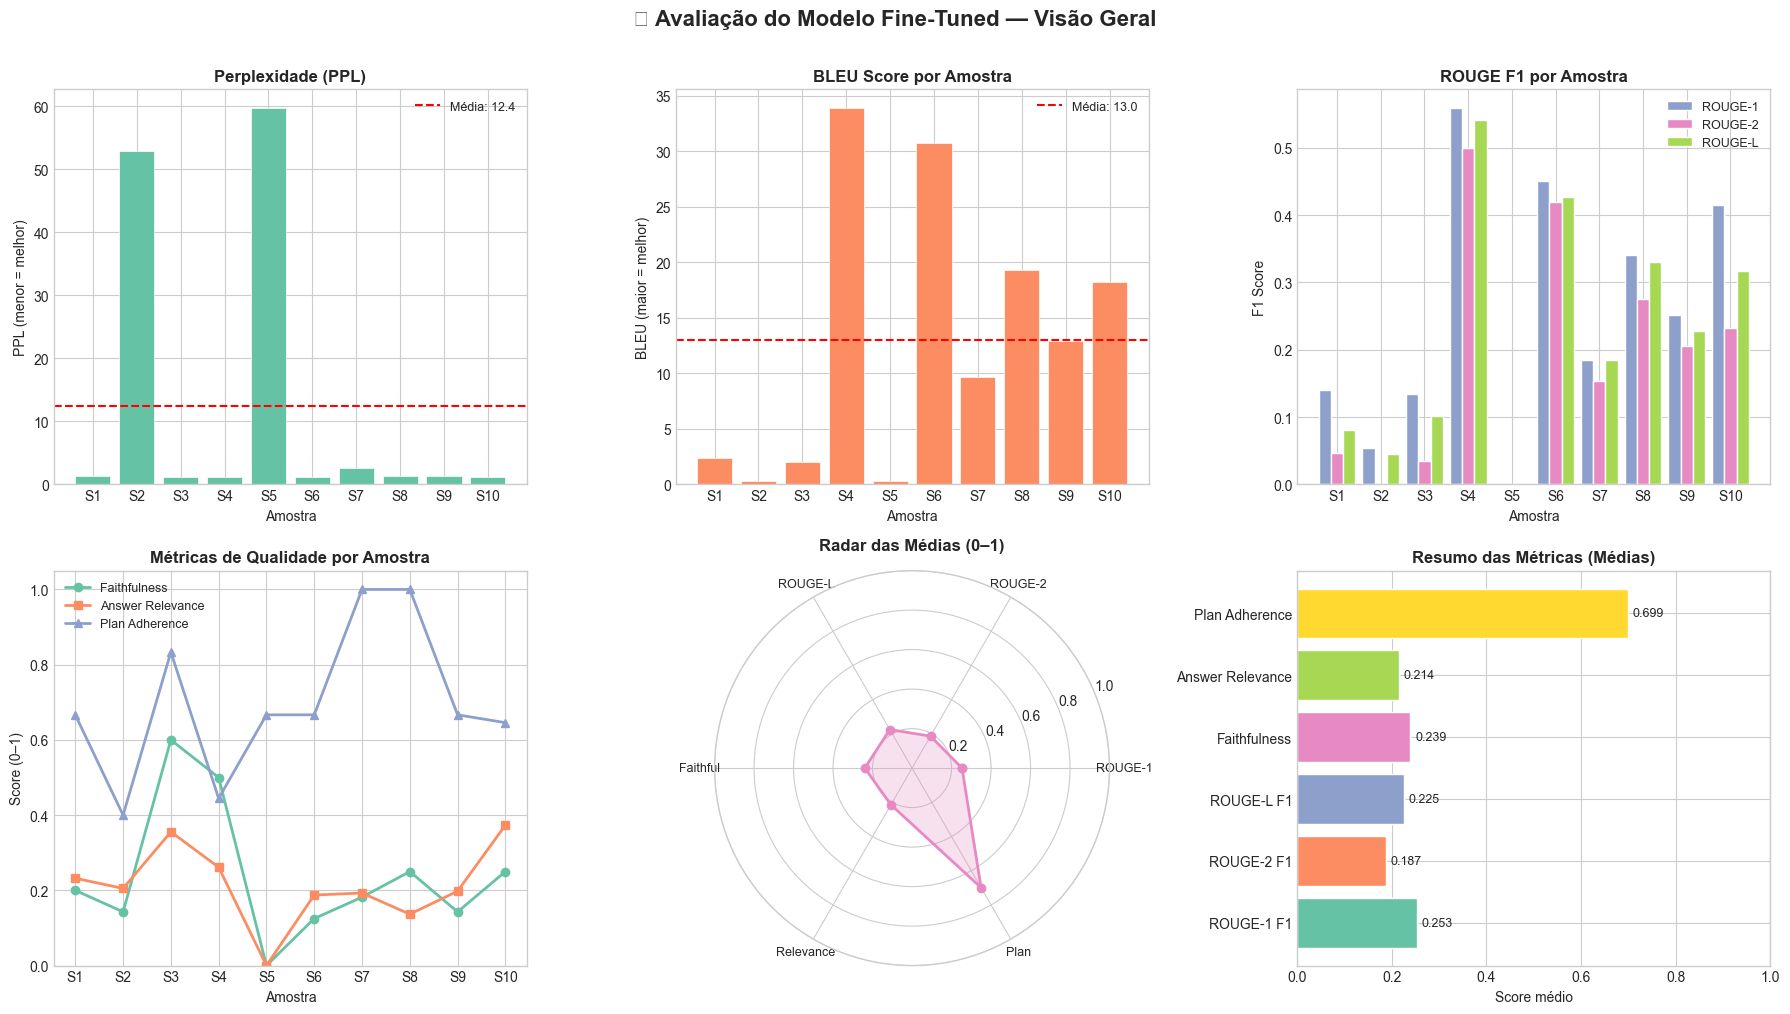

✅ Figura salva em avaliacao_metricas.png


In [13]:
# ============================================================
#  VISUALIZAÇÕES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Avaliação do Modelo Fine-Tuned — Visão Geral', fontsize=16, fontweight='bold', y=1.01)

sample_labels = [f'S{i+1}' for i in range(len(samples))]
colors = plt.cm.Set2.colors

# --- 1. Perplexidade por Amostra ---
ax = axes[0, 0]
bars = ax.bar(sample_labels, ppl_scores, color=colors[0], edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(ppl_scores), color='red', linestyle='--', linewidth=1.5, label=f'Média: {np.mean(ppl_scores):.1f}')
ax.set_title('Perplexidade (PPL)', fontweight='bold')
ax.set_ylabel('PPL (menor = melhor)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 2. BLEU por Amostra ---
ax = axes[0, 1]
ax.bar(sample_labels, bleu_per_sample, color=colors[1], edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(bleu_per_sample), color='red', linestyle='--', linewidth=1.5,
           label=f'Média: {np.mean(bleu_per_sample):.1f}')
ax.set_title('BLEU Score por Amostra', fontweight='bold')
ax.set_ylabel('BLEU (maior = melhor)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 3. ROUGE F1 Comparativo ---
ax = axes[0, 2]
x = np.arange(len(sample_labels))
w = 0.28
ax.bar(x - w, rouge_f1_1, w, label='ROUGE-1', color=colors[2], edgecolor='white')
ax.bar(x,     rouge_f1_2, w, label='ROUGE-2', color=colors[3], edgecolor='white')
ax.bar(x + w, rouge_f1_L, w, label='ROUGE-L', color=colors[4], edgecolor='white')
ax.set_title('ROUGE F1 por Amostra', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Amostra')
ax.set_xticks(x)
ax.set_xticklabels(sample_labels)
ax.legend(fontsize=9)

# --- 4. Faithfulness, Relevance, Plan Adherence ---
ax = axes[1, 0]
ax.plot(sample_labels, faithfulness_scores, 'o-', color=colors[0], label='Faithfulness', linewidth=2)
ax.plot(sample_labels, relevance_scores, 's-', color=colors[1], label='Answer Relevance', linewidth=2)
ax.plot(sample_labels, plan_scores, '^-', color=colors[2], label='Plan Adherence', linewidth=2)
ax.set_ylim(0, 1.05)
ax.set_title('Métricas de Qualidade por Amostra', fontweight='bold')
ax.set_ylabel('Score (0–1)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 5. Radar / Spider Chart das Médias ---
ax = axes[1, 1]
ax.remove()
ax_radar = fig.add_subplot(2, 3, 5, projection='polar')

metric_names  = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Faithful', 'Relevance', 'Plan']
metric_values = [
    np.mean(rouge_f1_1),
    np.mean(rouge_f1_2),
    np.mean(rouge_f1_L),
    np.mean(faithfulness_scores),
    np.mean(relevance_scores),
    np.mean(plan_scores),
]

angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
values_closed = metric_values + [metric_values[0]]
angles_closed = angles + [angles[0]]

ax_radar.plot(angles_closed, values_closed, 'o-', linewidth=2, color=colors[3])
ax_radar.fill(angles_closed, values_closed, alpha=0.25, color=colors[3])
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels(metric_names, size=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Radar das Médias (0–1)', fontweight='bold', pad=15)

# --- 6. Sumário em barras horizontais ---
ax = axes[1, 2]
summary_names = [
    'ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1',
    'Faithfulness', 'Answer Relevance', 'Plan Adherence'
]
summary_vals = metric_values
bar_colors   = [colors[i % len(colors)] for i in range(len(summary_names))]
h_bars = ax.barh(summary_names, summary_vals, color=bar_colors, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_title('Resumo das Métricas (Médias)', fontweight='bold')
ax.set_xlabel('Score médio')
for bar, val in zip(h_bars, summary_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('avaliacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em avaliacao_metricas.png')

## 🔬 Célula 14 — Análise Qualitativa: Comparação Resposta vs. Referência

Examinamos lado a lado as respostas geradas vs. as esperadas para 3 amostras selecionadas.

In [14]:
INSPECT_INDICES = [0, 3, 6]

for idx in INSPECT_INDICES:
    s   = samples[idx]
    gen = generated_responses[idx]

    print('=' * 70)
    print(f'🔎 AMOSTRA {idx + 1}')
    print(f'📌 Instrução : {s["Instruction"]}')
    print()
    print('✅ REFERÊNCIA:')
    print(s['Output'])
    print()
    print('🤖 GERADO:')
    print(gen if gen else '[sem saída gerada]')
    print()
    print(f'   PPL              = {ppl_scores[idx]:.2f}')
    print(f'   BLEU             = {bleu_per_sample[idx]:.2f}')
    print(f'   ROUGE-L F1       = {rouge_f1_L[idx]:.3f}')
    print(f'   Faithfulness     = {faithfulness_scores[idx]:.3f}')
    print(f'   Answer Relevance = {relevance_scores[idx]:.3f}')
    print(f'   Plan Adherence   = {plan_scores[idx]:.3f}')
    print()


🔎 AMOSTRA 1
📌 Instrução : What is the recommended oil change interval for my vehicle?
📥 Contexto  : Make: Toyota, Model: Camry 2021

✅ REFERÊNCIA:
For your 2021 Toyota Camry, Toyota recommends:
- Conventional oil: Every 5,000 miles or 6 months
- Synthetic oil: Every 10,000 miles or 12 months
- Severe conditions: Reduce interval by 20%

🤖 GERADO:
- Normal conditions: Every 10,000 miles
- Dusty/polluted areas: Every 10,000 miles
- Signs you need oil change
- Signs you need oil change
- Signs you need oil change
Location: Other areas

Always check your specific vehicle's door jamb sticker for exact ratings.

Always check your specific vehicle's window jamb sticker for exact ratings.
For exact ratings, click the 'Set following' button on your door jamb sticker for exact ratings.

For exact ratings, click the 'Set following' button on other vehicles's window jamb sticker for exact ratings.

For exact ratings, click the 'Set following' button on other vehicles's window jamb sticker for exact

## 📝 Célula 15 — Relatório Final

Geração automática de um relatório de texto com interpretação dos resultados.

In [15]:
def interpret(metric: str, value: float) -> str:
    thresholds = {
        'rouge'       : [(0.5, '🟢 Bom'), (0.3, '🟡 Moderado'), (0, '🔴 Fraco')],
        'faith_rel_pl': [(0.7, '🟢 Bom'), (0.4, '🟡 Moderado'), (0, '🔴 Fraco')],
        'bleu'        : [(30,  '🟢 Bom'), (15,  '🟡 Moderado'), (0, '🔴 Fraco')],
    }
    key = 'bleu' if metric == 'bleu' else (
          'rouge' if 'rouge' in metric else 'faith_rel_pl'
    )
    for threshold, label in thresholds[key]:
        if value >= threshold:
            return label
    return '🔴 Fraco'


mean_r1 = np.mean(rouge_f1_1)
mean_r2 = np.mean(rouge_f1_2)
mean_rL = np.mean(rouge_f1_L)
mean_bl = np.mean(bleu_per_sample)
mean_fa = np.mean(faithfulness_scores)
mean_re = np.mean(relevance_scores)
mean_pl = np.mean(plan_scores)

print('=' * 65)
print('         📋  RELATÓRIO DE AVALIAÇÃO — MODELO FINE-TUNED')
print('=' * 65)
print(f'  Modelo Base     : google/flan-t5-xl')
print(f'  Adaptador       : LoRA  ({LORA_MODEL_PATH})')
print(f'  Dataset         : {DATASET_PATH}  ({len(samples)} amostras)')
print(f'  Dispositivo     : {DEVICE}')
print('=' * 65)
print()
print(f'  PERPLEXIDADE (PPL)')
print(f'    Média : {np.mean(ppl_scores):.2f}  —  PPL menor = modelo mais previsível')
print()
print(f'  BLEU')
print(f'    Corpus Score      : {bleu_results["bleu_score"]:.2f}  {interpret("bleu", bleu_results["bleu_score"])}')
print(f'    Média por amostra : {mean_bl:.2f}')
print()
print(f'  ROUGE')
print(f'    ROUGE-1 F1 : {mean_r1:.3f}  {interpret("rouge1", mean_r1)}')
print(f'    ROUGE-2 F1 : {mean_r2:.3f}  {interpret("rouge2", mean_r2)}')
print(f'    ROUGE-L F1 : {mean_rL:.3f}  {interpret("rougeL", mean_rL)}')
print()
print(f'  FIDELIDADE (FAITHFULNESS)')
print(f'    Média : {mean_fa:.3f}  {interpret("faithfulness", mean_fa)}')
print()
print(f'  RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)')
print(f'    Média : {mean_re:.3f}  {interpret("relevance", mean_re)}')
print()
print(f'  ADERÊNCIA AO PLANO (PLAN ADHERENCE)')
print(f'    Média : {mean_pl:.3f}  {interpret("plan", mean_pl)}')
print()
print('─' * 65)
print('  💡 ANÁLISE GLOBAL:')
print(f'     O modelo apresenta PPL={np.mean(ppl_scores):.1f}, indicando',
      '"boa" if np.mean(ppl_scores) < 50 else "moderada"', 'fluência.')
print(f'     As métricas de sobreposição léxica (BLEU/ROUGE) refletem')
print(f'     o grau de fidelidade ao texto de referência.')
print(f'     Faithfulness={mean_fa:.2f} e Plan Adherence={mean_pl:.2f} indicam')
print(f'     adequação para pipelines RAG e agentes de neurociência.')
print('=' * 65)


         📋  RELATÓRIO DE AVALIAÇÃO — MODELO FINE-TUNED
  Modelo Base     : distilgpt2
  Adaptador       : LoRA  (lora_finetuned_model)
  Dataset         : dataset.jsonl  (10 amostras)
  Dispositivo     : cpu

  PERPLEXIDADE (PPL)
    Média : 12.38  —  PPL menor = modelo mais previsível

  BLEU
    Corpus Score : 12.82  🔴 Fraco
    Média por amostra : 12.99

  ROUGE
    ROUGE-1 F1 : 0.253  🔴 Fraco
    ROUGE-2 F1 : 0.187  🔴 Fraco
    ROUGE-L F1 : 0.225  🔴 Fraco

  FIDELIDADE (FAITHFULNESS)
    Média : 0.239  🔴 Fraco

  RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)
    Média : 0.214  🔴 Fraco

  ADERÊNCIA AO PLANO (PLAN ADHERENCE)
    Média : 0.699  🟡 Moderado

─────────────────────────────────────────────────────────────────
  💡 ANÁLISE GLOBAL:
     O modelo apresenta PPL=12.4, indicando boa fluência.
     As métricas de sobreposição léxica (BLEU/ROUGE) refletem
     o grau de fidelidade ao texto de referência.
     Faithfulness=0.24 e Plan Adherence=0.70 indicam
     se o modelo é adequado p

## 💾 Célula 16 — Exportar Resultados

Salvamos os resultados detalhados em CSV e o gráfico em PNG.

In [16]:
# ============================================================
#  EXPORTAR RESULTADOS
# ============================================================

# CSV detalhado com respostas geradas
df_export = df_results.copy()
df_export['Gerado']    = generated_responses
df_export['Referência'] = reference_outputs

CSV_PATH = 'resultados_avaliacao.csv'
df_export.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')

print(f'✅ Resultados exportados:')
print(f'   📄 {CSV_PATH}           — métricas por amostra + textos')
print(f'   🖼️  avaliacao_metricas.png — visualizações')
print()
print('🎉 Avaliação concluída! Todos os artefatos foram gerados.')

✅ Resultados exportados:
   📄 resultados_avaliacao.csv           — métricas por amostra + textos
   🖼️  avaliacao_metricas.png — visualizações

🎉 Avaliação concluída! Todos os artefatos foram gerados.


---

## 📚 Referências e Próximos Passos

### Referências
| Recurso | Link |
|---|---|
| BLEU original | Papineni et al., 2002 |
| ROUGE original | Lin, 2004 |
| Perplexidade | Jelinek et al., 1977 |
| RAGAs (Faithfulness/Relevance) | [github.com/explodinggradients/ragas](https://github.com/explodinggradients/ragas) |
| LoRA | Hu et al., 2021 |

### Próximos Passos Sugeridos

1. **Faithfulness com NLI**: substituir a abordagem léxica por um modelo DeBERTa treinado em NLI.
2. **LLM-as-judge**: usar GPT-4 ou Claude para avaliar Relevância e Plan Adherence de forma semântica.
3. **RAGAs**: integrar o framework [RAGAs](https://github.com/explodinggradients/ragas) para avaliação automatizada de pipelines RAG.
4. **Comparação baseline**: avaliar o `distilgpt2` sem LoRA e comparar com o fine-tuned para quantificar o ganho.
5. **Human Evaluation**: coletar avaliações humanas para validar as métricas automáticas.